# INTRODUCTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor as rfr
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score as r2
from sklearn.model_selection import train_test_split as tts
import warnings
warnings.filterwarnings("ignore")
import joblib

# Data Inspection

In [2]:
f = pd.read_csv("Walmart Feature.csv")
t = pd.read_csv("Walmart train.csv")
f["Date"] = pd.to_datetime(f["Date"])
t["Date"] = pd.to_datetime(t["Date"])
t.shape, f.shape
t.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False
421569,45,98,2012-10-26,1076.80,False


In [3]:
#df = pd.merge(f, t, on =["Store", "Date", "IsHoliday"])
#df = pd.concat([f, t], axis=1)
df = t.merge(
    f,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)
df["IsHoliday"] = df["IsHoliday"].map({True: 1, False: 0})
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,1,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,0,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,0,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,0,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In Time-Series Forecasting the most Important thinking is:

“Which columns are time-related?”

“Which column is my forecasting target?”

That forecasting mindset is the key 👀

# Sales Overtime Visualization

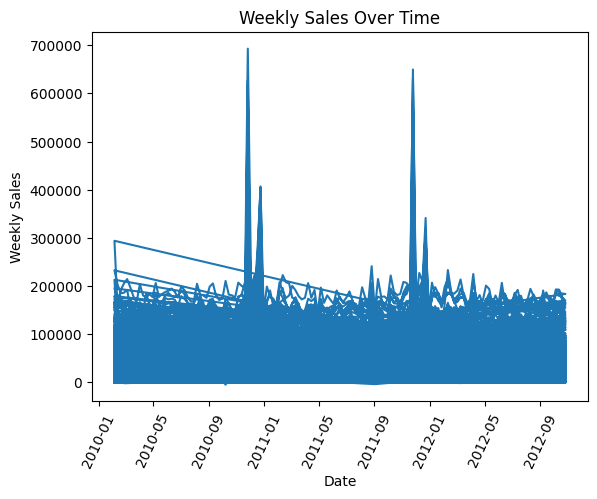

In [4]:
plt.plot(df["Date"], df["Weekly_Sales"])
plt.xticks(rotation=65)
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Over Time")
plt.show()

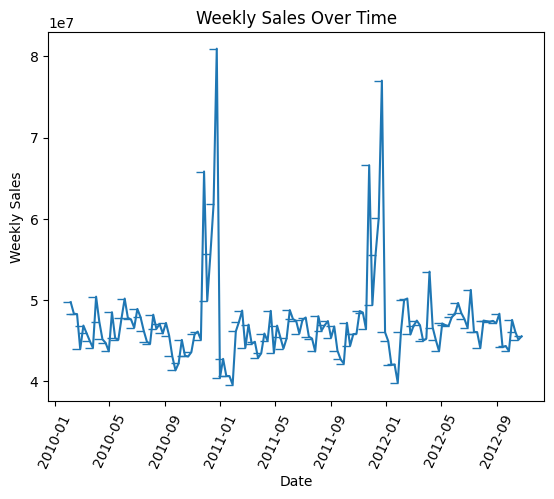

In [5]:
totalsales = df.groupby("Date")["Weekly_Sales"].sum().reset_index()
totalsales["Date"] = pd.to_datetime(totalsales["Date"])
totalsales.head()
plt.plot(totalsales["Date"], totalsales["Weekly_Sales"], marker=0)
plt.xticks(rotation=65)
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Over Time")
plt.show()

The spikes here are temporary seasonal surges not permanent growth

Sales average around 45M

# Forecasting is often less about:

correlation heatmaps

and more about:

patterns over time.

That’s a huge mindset shift from your previous ML projects.

# Sales and Moving Average Visualization

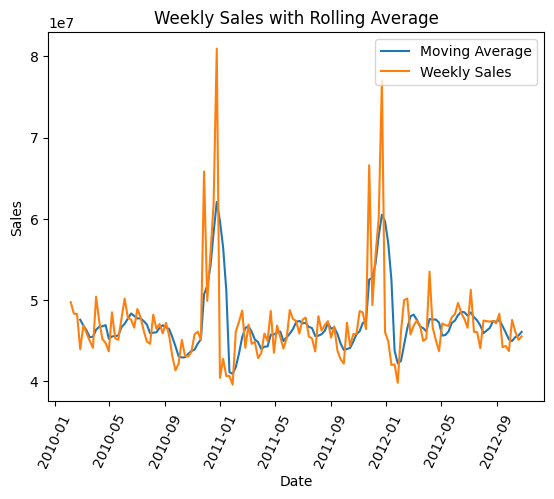

In [6]:
totalsales["moving_average"] = (totalsales["Weekly_Sales"].rolling(window=4).mean()) # 3-month moving average
#plt.plot(totalsales["Date"], totalsales["Weekly_Sales"])
plt.plot(totalsales["Date"], totalsales["moving_average"], label="Moving Average")
plt.plot(totalsales["Date"], totalsales["Weekly_Sales"], label="Weekly Sales")
plt.xticks(rotation=65)
plt.title("Weekly Sales with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()
#totalsales.head(20)

In classification projects:

you mostly cared about:

confusion matrix,,
accuracy,,
precision/recall.

But forecasting involves MUCH more:

visual understanding of patterns.

That’s why EDA matters heavily here.

# Date-Time Exraction

In [7]:
df["Year"]= df["Date"].dt.year
df["Month"]= df["Date"].dt.month
df["Week"]= df["Date"].dt.isocalendar().week
df["Quater"]= df["Date"].dt.quarter
df.shape

(421570, 18)

🚀 CORRECT FORECASTING SPLIT

Use:

older dates → training

newer dates → testing

Exactly like real life.

In [8]:
df = df.fillna(0)

# Feature Selection 1

In [9]:
x = df.drop(["Weekly_Sales","Store","Dept","Date"], axis=1)
y = df["Weekly_Sales"]
#

We are going to split "by date condition" instead of by sklearn train_test_split that we normally use because this is Time-Series Forecasting

🚫 Why random split is BAD here

If you randomly shuffle:

future dates leak into training

model indirectly sees the future

That gives:
❌ unrealistic performance

In [10]:
df = df.sort_values("Date")


In [11]:
future_date = "2012-01-01"

train = df[df["Date"] < future_date]
test = df[df["Date"] >= future_date]

In [12]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   IsHoliday     421570 non-null  int64  
 1   Temperature   421570 non-null  float64
 2   Fuel_Price    421570 non-null  float64
 3   MarkDown1     421570 non-null  float64
 4   MarkDown2     421570 non-null  float64
 5   MarkDown3     421570 non-null  float64
 6   MarkDown4     421570 non-null  float64
 7   MarkDown5     421570 non-null  float64
 8   CPI           421570 non-null  float64
 9   Unemployment  421570 non-null  float64
 10  Year          421570 non-null  int32  
 11  Month         421570 non-null  int32  
 12  Week          421570 non-null  UInt32 
 13  Quater        421570 non-null  int32  
dtypes: UInt32(1), float64(9), int32(3), int64(1)
memory usage: 39.0 MB


In [13]:
x_train = train[x.columns]
y_train = train[y.name]
x_test = test[x.columns]
y_test = test[y.name]

Why .columns and .name for x and y is because x contains DataFrame(columns) and y contains Series(one column)

# Model Integration

In [14]:
model = rfr(n_estimators=20, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

In [15]:
predict = model.predict(x_test)

# Model Evaluation 1

In [16]:
Goodness_of_fit = r2(y_test, predict)
root_mean = rmse(y_test, predict)

print("Goodness of fit:", Goodness_of_fit)
print("Root mean square error:", root_mean)

Goodness of fit: 0.0038919481545849344
Root mean square error: 22077.368619701683


🧠 What it means

Your model explains:

less than 1% of the sales variation.(Goodness of fit)

Meaning:

the model barely learned useful forecasting patterns.

your predictions are off by roughly:

±22,000 sales units on average.(RMSE)

That’s large.

This is EXTREMELY common in forecasting.

Especially when:

raw retail data is noisy,
multiple stores mixed together,
departments mixed together,
weak features,
no lag features yet.

Traditional ML:
features may already contain strong signals.

Forecasting:
you often CREATE the strongest features manually.

# Lag Feature Creation

In [17]:
df["Lag_1"] =df["Weekly_Sales"].shift(1)
df["Lag_2"] =df["Weekly_Sales"].shift(2)
df["Lag_3"] =df["Weekly_Sales"].shift(3)
df["Lag_4"] =df["Weekly_Sales"].shift(4)

🧠 VERY IMPORTANT FORECASTING INSIGHT

Lag features are often:

more important than external features.

Sometimes:

previous sales alone can outperform:

weather,
economics,
promotions

That’s how powerful temporal dependency is.

In [18]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,CPI,Unemployment,Year,Month,Week,Quater,Lag_1,Lag_2,Lag_3,Lag_4
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,211.096358,8.106,2010,2,5,1,NaN,NaN,NaN,NaN
277665,29,5,2010-02-05,15552.08,0,24.36,2.788,0.0,0.0,0.0,...,131.527903,10.064,2010,2,5,1,24924.50,NaN,NaN,NaN
277808,29,6,2010-02-05,3200.22,0,24.36,2.788,0.0,0.0,0.0,...,131.527903,10.064,2010,2,5,1,15552.08,24924.50,NaN,NaN
277951,29,7,2010-02-05,10820.05,0,24.36,2.788,0.0,0.0,0.0,...,131.527903,10.064,2010,2,5,1,3200.22,15552.08,24924.50,NaN
278094,29,8,2010-02-05,20055.64,0,24.36,2.788,0.0,0.0,0.0,...,131.527903,10.064,2010,2,5,1,10820.05,3200.22,15552.08,24924.5


In [19]:
tag = df[["IsHoliday", "Month", "Lag_1", "Lag_2", "Lag_3", "Lag_4", "Weekly_Sales"]]

In [20]:
x = df[["IsHoliday", "Month", "Lag_1", "Lag_2", "Lag_3", "Lag_4"]]
y = df["Weekly_Sales"]

train = df[df["Date"] < future_date]
test = df[df["Date"] >= future_date]

x_train = train[x.columns]
y_train = train[y.name]
x_test = test[x.columns]
y_test = test[y.name]

# Model Creation

In [21]:
model = rfr(n_estimators=20, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

# Model Evaluation 2

In [22]:
predict = model.predict(x_test)
Goodness_of_fit = r2(y_test, predict)
root_mean = rmse(y_test, predict)

print("Goodness of fit:", Goodness_of_fit)
print("Root mean square error:", root_mean)

Goodness of fit: -0.08751145399665106
Root mean square error: 23068.056346796784


🧠 Right now your dataset contains MANY time series at once

This means:

you are not forecasting:

ONE sales sequence.

You are forecasting:

MANY sequences mixed together.

That becomes much more complex.

Thats why we will be using the "totalsales" dataframe now instead

# Feature Engineering

In [23]:
totalsales["Lag_1"] = totalsales["Weekly_Sales"].shift(1)
totalsales["Lag_2"] = totalsales["Weekly_Sales"].shift(2)
#totalsales["Lag_3"] = totalsales["Weekly_Sales"].shift(3)
totalsales["Lag_4"] = totalsales["Weekly_Sales"].shift(4)
#totalsales["Lag_8"] = totalsales["Weekly_Sales"].shift(8)
#totalsales["Lag_12"] = totalsales["Weekly_Sales"].shift(12)
#totalsales["Rolling_Mean_4"] = totalsales["Weekly_Sales"].shift(1).rolling(window=4).mean()
#totalsales["Expanding_Mean"] = totalsales["Weekly_Sales"].shift(1).expanding().mean()
#totalsales["Month"] = totalsales["Date"].dt.month
#totalsales["Year"] = totalsales["Date"].dt.year
totalsales["Week"] = totalsales["Date"].dt.isocalendar().week
totalsales = totalsales.dropna()
totalsales.shape

(139, 7)

🚀 WHY shift(1) before rolling(window=4)?

This ensures:
current prediction only uses:

past information.

VERY important forecasting concept.

In [24]:
x = totalsales[["Lag_1", "Lag_2", "Lag_4", "Week"]]
y = totalsales["Weekly_Sales"]

train = totalsales[totalsales["Date"] < future_date]
test = totalsales[totalsales["Date"] >= future_date]

x_train = train[x.columns]
y_train = train[y.name]
x_test = test[x.columns]
y_test = test[y.name]

In [25]:
x.head()

,Lag_1,Lag_2,Lag_4,Week
4,43968571.13,48276993.78,49750740.50,9
5,46871470.30,43968571.13,48336677.63,10
6,45925396.51,46871470.30,48276993.78,11
7,44988974.64,45925396.51,43968571.13,12
8,44133961.05,44988974.64,46871470.30,13


# Model Creation and Training

In [26]:
model = rfr(n_estimators=20, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

# Model Evaluation

In [27]:
predict = model.predict(x_test)
Goodness_of_fit = r2(y_test, predict)
root_mean = rmse(y_test, predict)

print("Goodness of fit:", Goodness_of_fit)
print("Root mean square error:", root_mean)

Goodness of fit: 0.36730054220438313
Root mean square error: 1937370.842207791


Goodness of fit: 0.347054396074715
Root mean square error: 1968124.3258702313


more features ≠ better model.

That is a HUGE realization.

Part of cause of reduction in r2 is the reduction in dataset 131 rows and OVERFITTING-- me increasing n_estimators to 150 and addition of more features

**Some New Features May Be Redundant**

Example:

- Lag_1
- Rolling_Mean_4
- Expanding_Mean

all partially describe:

recent sales behavior.

Too much similar information can confuse models sometimes.

# Actual and Predicted Sales Visualization

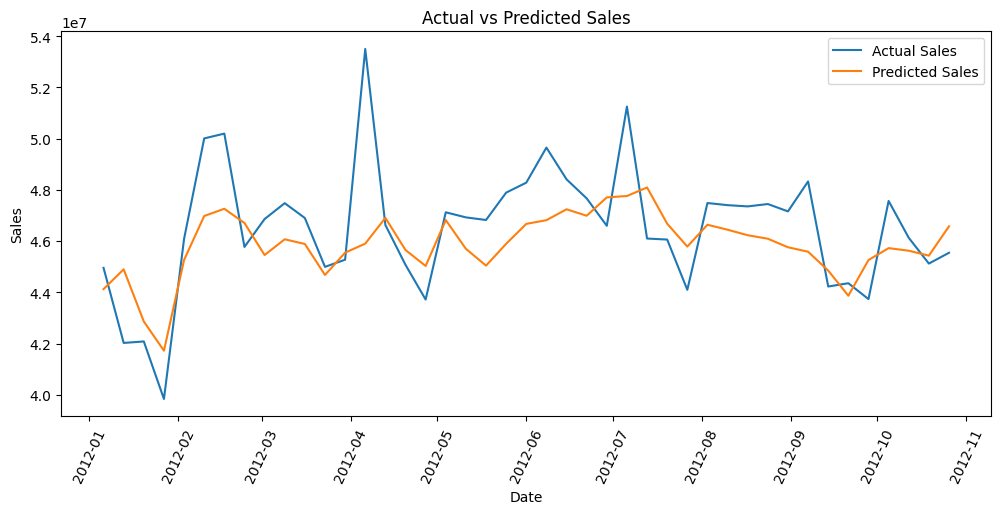

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    test["Date"],
    y_test,
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    predict,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.xticks(rotation=65)
plt.ylabel("Sales")

plt.legend()

plt.show()

# When training forecasting models, always ensure rolling statistics are lagged so they don't include the current value you're trying to predict!

# “How do we forecast the future that does not exist yet?”
So to predict:

next week sales

you must supply:

- last week's sales
- weeks ago sales,
- weeks ago sales,
- next week's month/week/year,

# EXAMPLE in Code
STEP 2 — Build future row

Example:

future_data = pd.DataFrame({
    "Lag_1": [latest_sales],
    "Lag_2": [sales_2_weeks_ago],
    "Lag_4": [sales_4_weeks_ago],
    "Month": [next_month],
    "Week": [next_week],
    "Year": [next_year]
})
STEP 3 — Predict future sales

future_prediction = model.predict(future_data)

print(future_prediction)

# Feature Importance Extraction

In [29]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({"Feature": x.columns, "Importance": importance})
feature_importance = feature_importance.sort_values("Importance", ascending=False)
feature_importance

,Feature,Importance
3,Week,0.573657
2,Lag_4,0.191688
0,Lag_1,0.185104
1,Lag_2,0.049550


👉 Week being dominant means:

your model strongly learned:

seasonal timing patterns.

Meaning:
certain weeks repeatedly behave similarly.

Example:

- holiday weeks
- Black Friday periods
- year-end shopping weeks

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

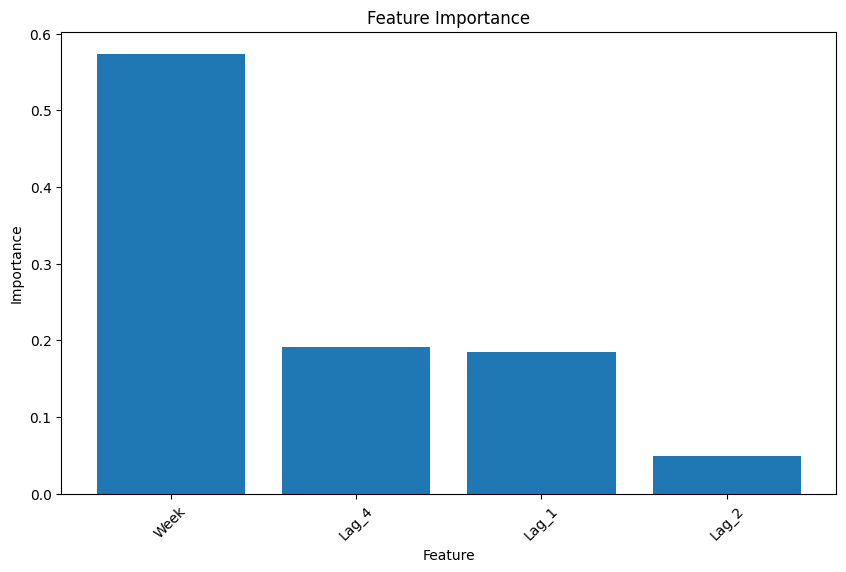

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt

In [32]:
latest_sales = totalsales.tail(4)["Weekly_Sales"].values
history = list(totalsales["Weekly_Sales"].tail(4))
history

[47566639.31, 46128514.25, 45122410.57, 45544116.29]

In [33]:
print(x.columns)

Index(['Lag_1', 'Lag_2', 'Lag_4', 'Week'], dtype='object')


# Next 4-Weeks Forecast/Prediction

In [34]:
future_pred = []

current_week = totalsales["Week"].iloc[-1]
#current_year = totalsales["Year"].iloc[-1]

for i in range(4):

    future_data = pd.DataFrame({
        "Lag_1": [history[-1]],
        "Lag_2": [history[-2]],
        "Lag_4": [history[-4]],
        #"Month": [1],   # temporary

        "Week": [current_week + i + 1],

    })

    pred = model.predict(future_data)[0]

    future_pred.append(pred)

    history.append(pred)

In [35]:
print(future_pred)

[np.float64(46534988.85649999), np.float64(46602195.264499985), np.float64(46884026.252), np.float64(60680360.297000006)]


Forecast Loop

# Next 4-Weeks Forecast Visualization

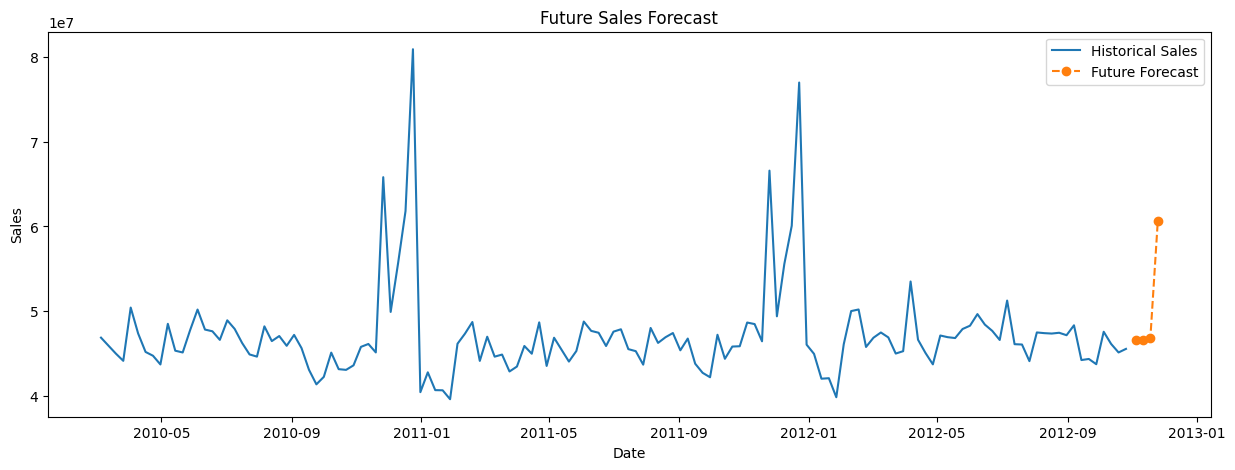

In [40]:
future_dates = pd.date_range(
    start=totalsales["Date"].iloc[-1],
    periods=5,
    freq="W"
)[1:]

plt.figure(figsize=(15,5))

# Historical sales
plt.plot(
    totalsales["Date"],
    totalsales["Weekly_Sales"],
    label="Historical Sales"
)

# Future forecast
plt.plot(
    future_dates,
    future_pred,
    marker="o",
    linestyle="--",
    label="Future Forecast"
)

plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

# Saving Dataset

In [ ]:
totalsales.to_csv("SalesData.csv", index=False)
#

# Saving Model

In [ ]:
joblib.dump(model, "forecast_model.pkl")

# Findings
More n_estimators for small dataset wont help increase r2 percentage and more lag features doesnt guarantee higher predictive accuracy

Week dominate in feature importance due to some certain reasons
- holiday weeks
- Black Friday periods
- year-end shopping weeks

predicted sales doesnt really aligned well with actual sales but At times knowing when to stop improving model is also an ML skill

# Conclusion
So after all the tweeking and all the feature engineering and feature selections, i later had to use 20 n_estimators instead of 100 because of the reduction in dataset and i only use lag 1,2 and 4 and week as feature because that have better feature importance that helps increase percentage of r2(Accuracy)